In [1]:

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


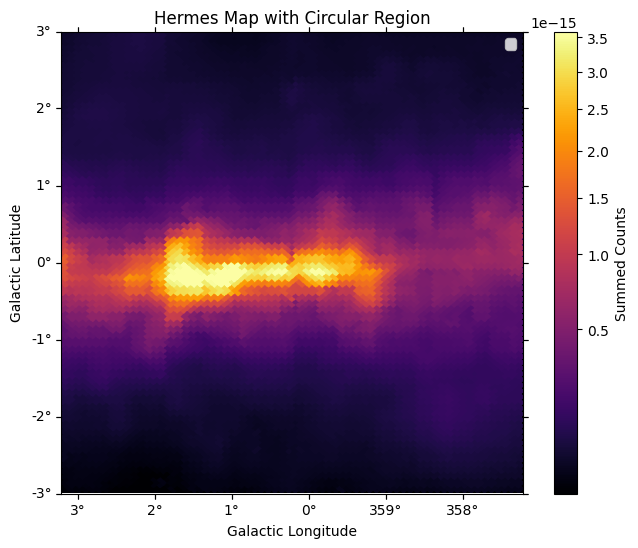

In [2]:
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import skycoord_to_pixel
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits
from pandas import read_csv
from astropy.visualization import simple_norm
from matplotlib.patches import Circle
from astropy.wcs.utils import proj_plane_pixel_scales
HERMES_PATH = "/Users/rishi/Documents/Analysis/2027/Hermes-GC.fits.gz"
# HERMES_PATH = '/Users/rishi/Documents/Analysis/2027/skymap-E_min_0.1TeV_max_2107.8313611484987TeV_Eidx0.1TeV-Pi0H2.fits.gz'
f = fits.open(HERMES_PATH)
data = f[0].data      
header = f[0].header
wcs = WCS(header)
image = data[0]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': wcs.celestial})
norm = simple_norm(image, 'sqrt', percent=99)
im = ax.imshow(image, origin='lower', cmap='inferno', norm=norm)

ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")
ax.set_title("Hermes Map with Circular Region")
plt.colorbar(im, ax=ax, label="Summed Counts")
ax.legend(loc='upper right')
plt.show()

Length of bins=640


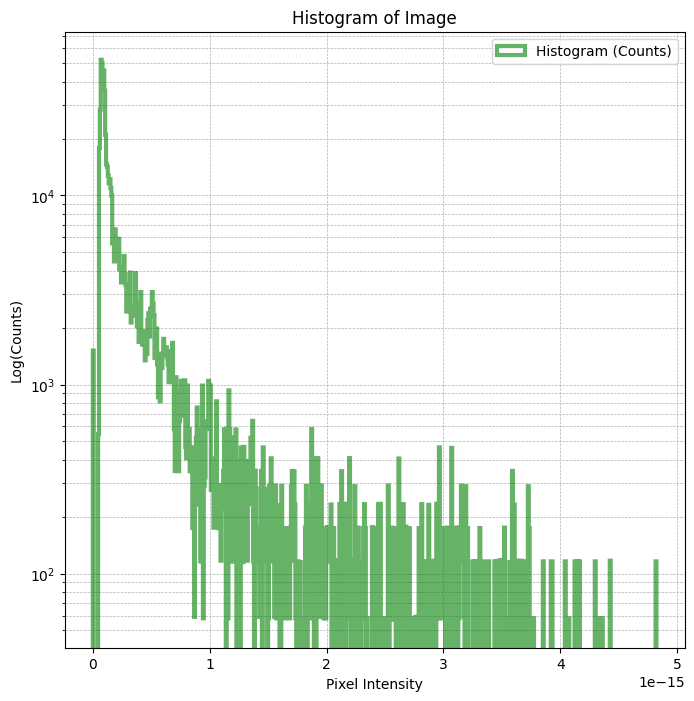

In [3]:
# Calculate the 1D histogram of the image
pixels = image.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
# plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
# plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
# plt.ylim(0.5, 1e6)
# plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

In [6]:
#Normalize the image between 0 and 1 for analysis
array = image
image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


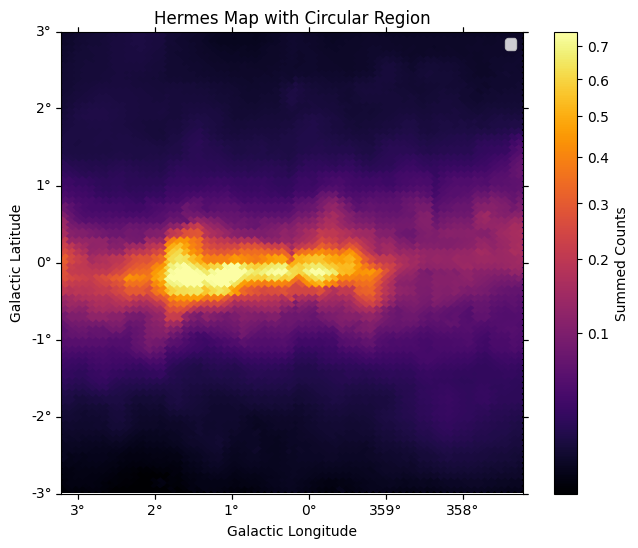

In [7]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': wcs.celestial})
norm = simple_norm(norm_image, 'sqrt', percent=99)
im = ax.imshow(norm_image, origin='lower', cmap='inferno', norm=norm)

ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")
ax.set_title("Hermes Map with Circular Region")
plt.colorbar(im, ax=ax, label="Summed Counts")
ax.legend(loc='upper right')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.007337501991231392 0.33987096432799924


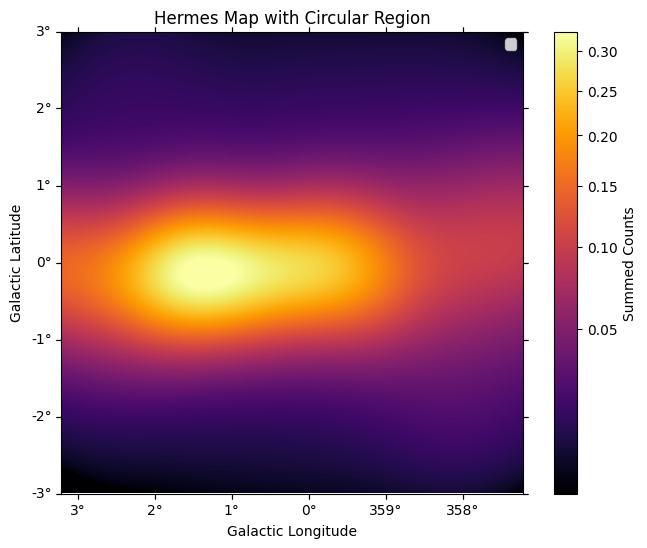

In [8]:
#Smearing Image with a gaussian for visualizing 
image_tmp = norm_image
smear_radius = 0.5
pixel_size = 0.0075
smear_image = gaussian(image_tmp, sigma=smear_radius/0.0075)
print(np.min(smear_image), np.max(smear_image))

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': wcs.celestial})
norm = simple_norm(smear_image, 'sqrt', percent=99)
im = ax.imshow(smear_image, origin='lower', cmap='inferno', norm=norm)

ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")
ax.set_title("Hermes Map with Circular Region")
plt.colorbar(im, ax=ax, label="Summed Counts")
ax.legend(loc='upper right')
plt.show()


106.66666666666667


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


-0.1098509166720743 0.7816521181917602


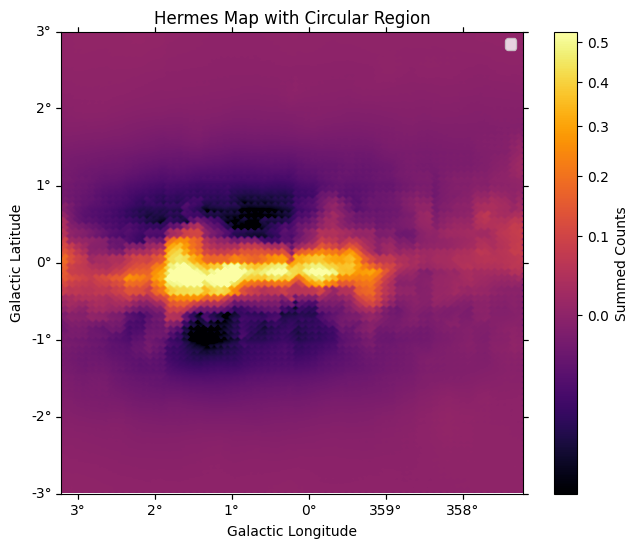

In [10]:
psf=0.8           #PSF of the dec band
print(psf/pixel_size)
dog_image = difference_of_gaussians(norm_image, 1, psf/pixel_size)
print(np.min(dog_image), np.max(dog_image))

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': wcs.celestial})
norm = simple_norm(dog_image, 'sqrt', percent=99)
im = ax.imshow(dog_image, origin='lower', cmap='inferno', norm=norm)

ax.set_xlabel("Galactic Longitude")
ax.set_ylabel("Galactic Latitude")
ax.set_title("Hermes Map with Circular Region")
plt.colorbar(im, ax=ax, label="Summed Counts")
ax.legend(loc='upper right')
plt.show()


In [11]:
threshold_val = 0.01
psf=0.2 
ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=threshold_val, exclude_border=10, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))

ext_blobs = blob_dog(dog_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < psf/pixel_size]
# ext_blobs = ext_blobs[ext_blobs[:, 2] > psf/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))


# intensity_min = deviation_location
intensity_min = 0
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ext = ", len(ext_filtered_blobs))

# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}

Number of point source blobs= 9
Number of ext source blobs= 3
Number of point source blobs= 9
Number of ext source blobs= 3
Blob Intensity 0.6263870970036557, Coords (267.2126831963488 deg, -28.134008666111928 deg), Radius 21.333333333333336, Pixel Radius 0.16
Blob Intensity 0.5822367112436327, Coords (267.5326471795688 deg, -27.64771054030221 deg), Radius 21.333333333333336, Pixel Radius 0.16
Blob Intensity 0.48173869380585965, Coords (266.4093592059131 deg, -29.10985417912641 deg), Radius 21.333333333333336, Pixel Radius 0.16
Blob Intensity 0.5030630153681496, Coords (266.7562989446212 deg, -28.653810104689 deg), Radius 13.333333333333334, Pixel Radius 0.1
Blob Intensity 0.22214520608369928, Coords (267.97364164916615 deg, -27.07786068780987 deg), Radius 13.333333333333334, Pixel Radius 0.1
Blob Intensity 0.054510629547591435, Coords (264.4128111290238 deg, -30.558530872649637 deg), Radius 13.333333333333334, Pixel Radius 0.1
Blob Intensity 0.002375216589816511, Coords (265.539375378